In [ ]:
import sys
sys.dont_write_bytecode = True
%load_ext autoreload
%autoreload 1
%aimport classify_dice
import classify_dice
from ultralytics import YOLO
import sklearn
import cv2
from matplotlib import pyplot as plt
import numpy as np
import einops

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


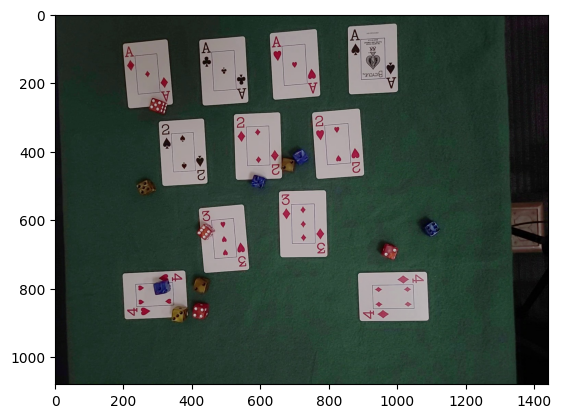

In [36]:
def imshow(img):
    return plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

obb_model = YOLO("model/rdg_obb/weights/best.pt")

example_frame = "data/frames/frame_0214.jpg"
img = cv2.imread(example_frame)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
imshow(img)

In [ ]:
res = obb_model(img, task='obb')[0]
res

In [ ]:
res[0].obb

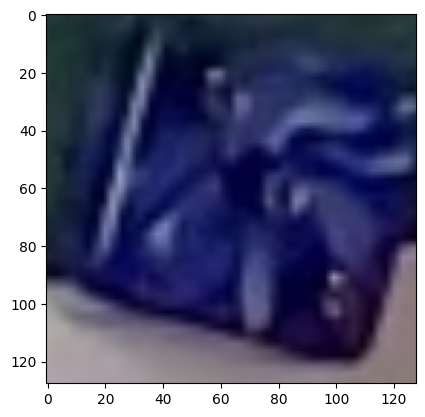

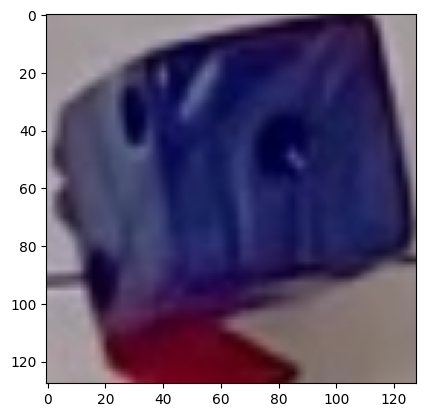

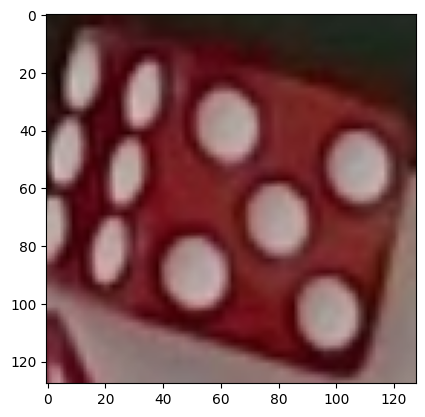

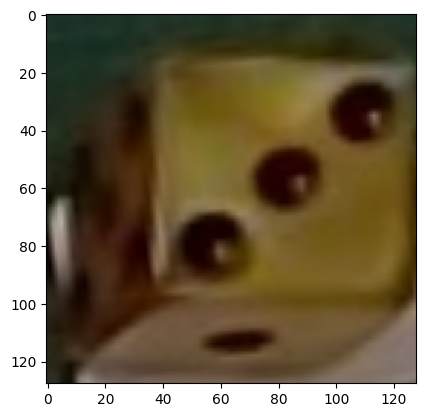

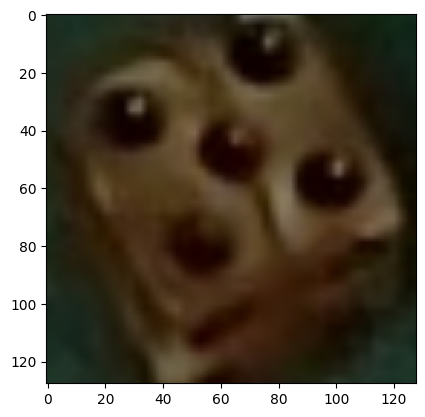

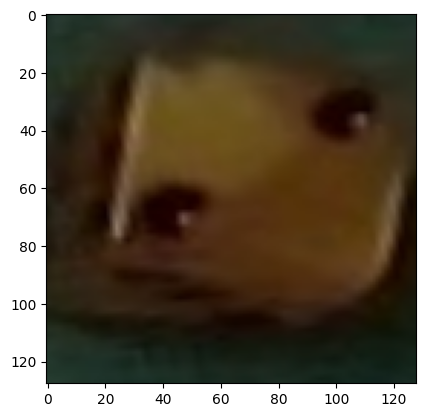

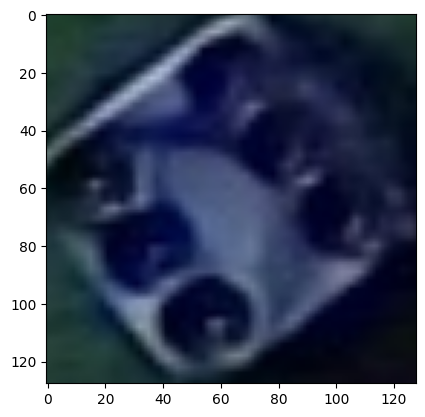

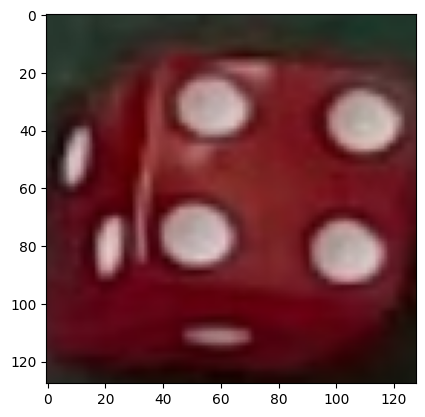

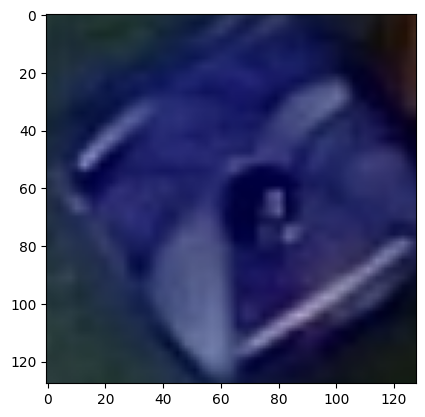

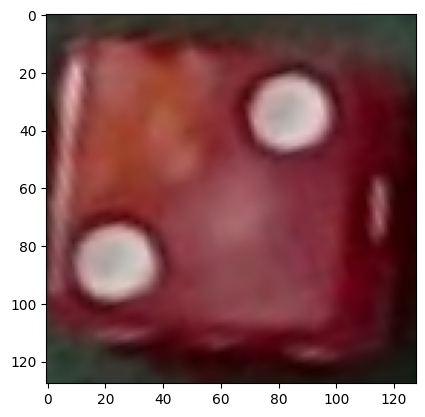

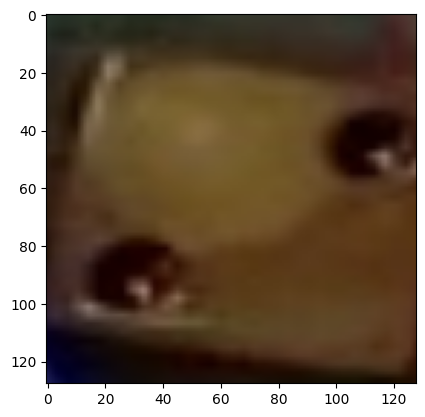

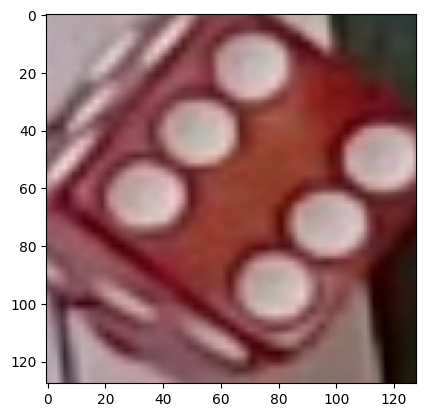

In [63]:
dice_cropped = classify_dice.batch_crop_dice(img, res)

for die_idx in range(dice_cropped.shape[0]):
    plt.figure()
    classify_dice.imshow(dice_cropped[die_idx,:,:,:])

In [125]:
def kmeans_color(imgs, k=16):
    N,H,W,C = imgs.shape
    k_means = sklearn.cluster.KMeans(n_clusters=k, random_state=1337, n_init=10)

    colors = einops.rearrange(imgs, "N H W C -> (N H W) C")
    return k_means.fit(colors)

kmr = kmeans_color(dice_cropped)

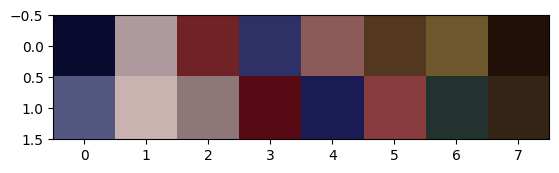

In [126]:
colors = []
for c_idx in range(kmr.cluster_centers_.shape[0]):
    color = kmr.cluster_centers_[c_idx,:]
    colors.append(color)
    # plt.figure()
    # classify_dice.imshow(color.reshape(1,1,3).astype(np.uint8))
    # plt.show()
colors = np.stack(colors, axis=0).astype(np.uint8)
classify_dice.imshow(einops.rearrange(colors, "(h w) C -> h w C", w=8))

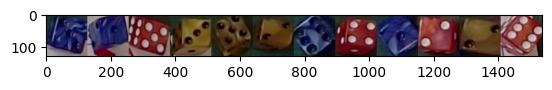

In [ ]:
classify_dice.imshow(einops.rearrange(dice_cropped, "N H W C-> W (N W) C"))

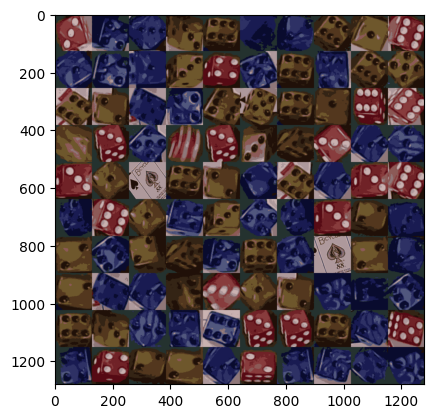

In [ ]:
# recolor dice using this limited palette

dice_cropped_old = dice_cropped
dice_cropped = all_dice

n_dice,h,w,_ = dice_cropped.shape
flat_in = einops.rearrange(dice_cropped, "N H W C -> (N H W) C")
flat_out = kmr.predict(flat_in)
flat_colors = colors[flat_out,:]
classes = einops.rearrange(flat_out, "(N H W) -> N H W", N=n_dice, H=h, W=w)
posterized = einops.rearrange(flat_colors, "(N H W) C -> N H W C", N=n_dice, H=h, W=w, C=3)

dice_cropped = dice_cropped_old

sample_idxs = np.random.permutation(posterized.shape[0])[:100]
classify_dice.imshow(einops.rearrange(posterized[sample_idxs,...], "(N x) H W C -> (N H) (x W) C", x=10))


In [ ]:

img.shape

(1080, 1440, 3)

In [ ]:
img

In [132]:
all_dice = classify_dice.generate_dice_dataset(obb_model)


0: 384x512 4 aces, 3 twos, 2 threes, 2 fours, 6.1ms
Speed: 1.1ms preprocess, 6.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 1 die, 4 aces, 3 twos, 2 threes, 2 fours, 5.2ms
Speed: 0.9ms preprocess, 5.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 2 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 3 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)



0: 384x512 4 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 5 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 5 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 6 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 7 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 8 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.1ms
Speed: 1.3ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

0: 384x512 9 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.2m

In [ ]:
np.savez_compressed('data/dice/all_dice.npz', all_dice.astype(np.uint8))

In [ ]:
all_dice = np.load('data/dice/all_dice.npz')['arr_0']
classify_dice.write_dice()